In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
X = [50, 60, 70, 80, 90]       
y = [150, 180, 210, 240, 270]     

In [20]:
X = np.array(X, dtype=float)
y = np.array(y, dtype=float)

In [21]:
class LinearRegressionGD:
    """Simple Linear Regression trained with Batch Gradient Descent."""

    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0          # intercept
        self.theta_1 = 0.0          # slope
        self.sse_history = []       # SSE at each iteration

    # ---------- helpers ----------
    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.theta_0 + self.theta_1 * X

    def sse(self, X, y):
        residuals = y - self.predict(X)
        return np.sum(residuals ** 2)

    def mse(self, X, y):                    # Bonus task
        residuals = y - self.predict(X)
        return np.mean(residuals ** 2)

    # ---------- training ----------
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        n = len(X)

        self.theta_0, self.theta_1 = 0.0, 0.0
        self.sse_history = []

        for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error  = y - y_pred                      # residuals

            self.sse_history.append(np.sum(error ** 2))

            # gradients
            d_theta_0 = -(2 / n) * np.sum(error)
            d_theta_1 = -(2 / n) * np.sum(error * X)

            # update rule
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

        return self

    # ---------- visualization ----------
    def plot_training(self, X=None, y=None):
        fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

        # (a) SSE over iterations
        ax[0].plot(range(len(self.sse_history)), self.sse_history, color="crimson")
        ax[0].set_title("SSE over iterations")
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("SSE")
        ax[0].grid(alpha=.3)
        if np.all(np.array(self.sse_history) > 0):
            ax[0].set_yscale("log")          # log scale عشان نشوف النزول بوضوح
            ax[0].set_ylabel("SSE (log scale)")

        # (b) regression line + data points
        if X is not None and y is not None:
            X = np.array(X, dtype=float)
            ax[1].scatter(X, y, color="royalblue", s=60, label="Data points")
            xs = np.linspace(X.min(), X.max(), 100)
            ax[1].plot(xs, self.predict(xs), color="darkorange", lw=2,
                       label=f"y = {self.theta_0:.2f} + {self.theta_1:.2f}x")
            ax[1].set_title("Regression line vs data")
            ax[1].set_xlabel("House size (m²)")
            ax[1].set_ylabel("Price (thousands)")
            ax[1].legend()
            ax[1].grid(alpha=.3)

        plt.tight_layout()
        plt.show()

In [22]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print("theta_0 =", model.theta_0)
print("theta_1 =", model.theta_1)
print("Final SSE =", model.sse_history[-1])

theta_0 = -1.0055957901462392e+95
theta_1 = -7.326427288635144e+96
Final SSE = 1.6170789775172399e+196


In [24]:
model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
model.fit(X, y)

print("theta_0 =", round(model.theta_0, 6))
print("theta_1 =", round(model.theta_1, 6))
print("Final SSE =", round(model.sse_history[-1], 8))
print("Final MSE =", round(model.mse(X, y), 8))

theta_0 = 0.041137
theta_1 = 2.999435
Final SSE = 0.00033182
Final MSE = 6.636e-05


In [25]:
size = 70
predicted_price = model.predict(size)

print(f"Predicted price for a {size} m² house = {float(predicted_price):.2f} thousand")

Predicted price for a 70 m² house = 210.00 thousand


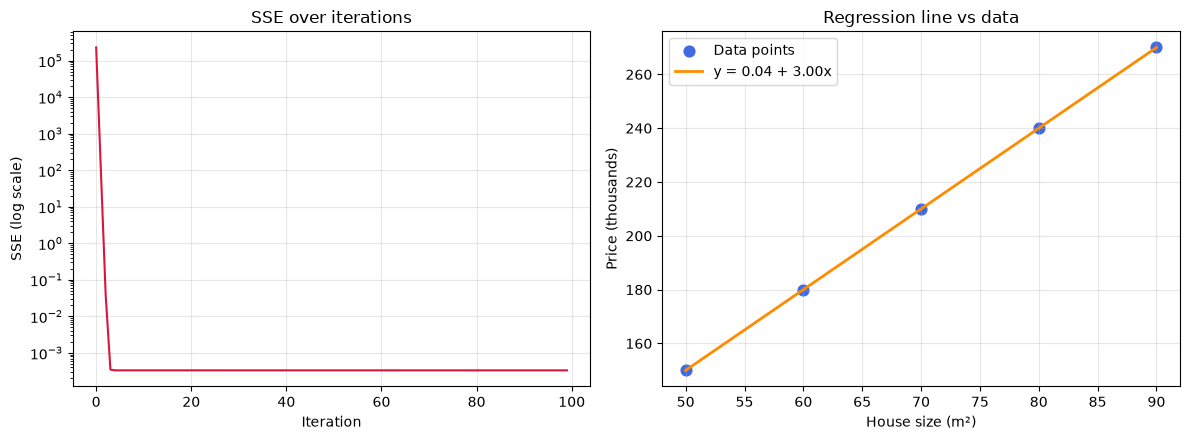

In [26]:
model.plot_training(X, y)

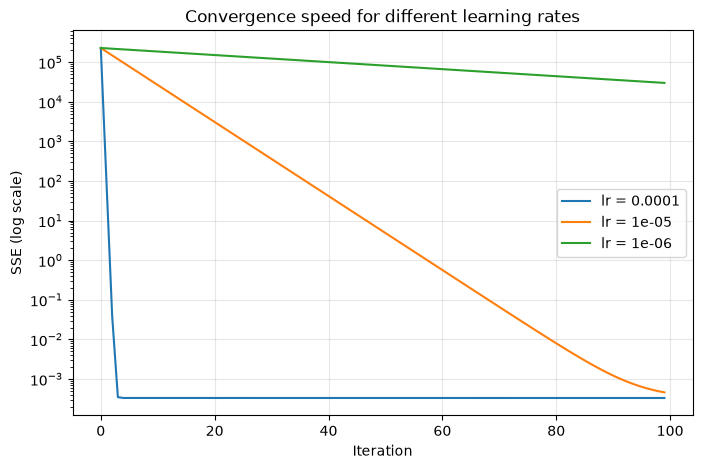

In [ ]:
plt.figure(figsize=(8, 5))
for lr in [0.0001, 0.00001, 0.000001]:
    m = LinearRegressionGD(learning_rate=lr, n_iters=100).fit(X, y)
    plt.plot(m.sse_history, label=f"lr = {lr}")
plt.yscale("log")
plt.xlabel("Iteration"); plt.ylabel("SSE (log scale)")
plt.title("Convergence speed for different learning rates")
plt.legend(); plt.grid(alpha=.3)
plt.show()

In [28]:
m = LinearRegressionGD(learning_rate=0.0001, n_iters=100).fit(X, y)
print("SSE =", m.sse(X, y))
print("MSE =", m.mse(X, y))
print("RMSE =", np.sqrt(m.mse(X, y)), "thousand")

SSE = 0.00033181040381498436
MSE = 6.636208076299688e-05
RMSE = 0.008146292455037254 thousand


In [ ]:
X_mean, X_std = X.mean(), X.std()
X_norm = (X - X_mean) / X_std

print("X normalized:", np.round(X_norm, 4))

m_norm = LinearRegressionGD(learning_rate=0.001, n_iters=100).fit(X_norm, y)
print("\n[Normalized] theta_0 =", round(m_norm.theta_0, 4),
      "| theta_1 =", round(m_norm.theta_1, 4),
      "| SSE =", round(m_norm.sse_history[-1], 4))

m_raw = LinearRegressionGD(learning_rate=0.001, n_iters=100).fit(X, y)
print("[Raw]        SSE =", m_raw.sse_history[-1], "  <-- diverged")

X normalized: [-1.4142 -0.7071  0.      0.7071  1.4142]

[Normalized] theta_0 = 38.101 | theta_1 = 7.6976 | SSE = 154393.803
[Raw]        SSE = 1.6170789775172399e+196   <-- diverged


[Normalized, lr=0.1] theta_0 = 210.0 | theta_1 = 42.4264 | SSE = 0.0


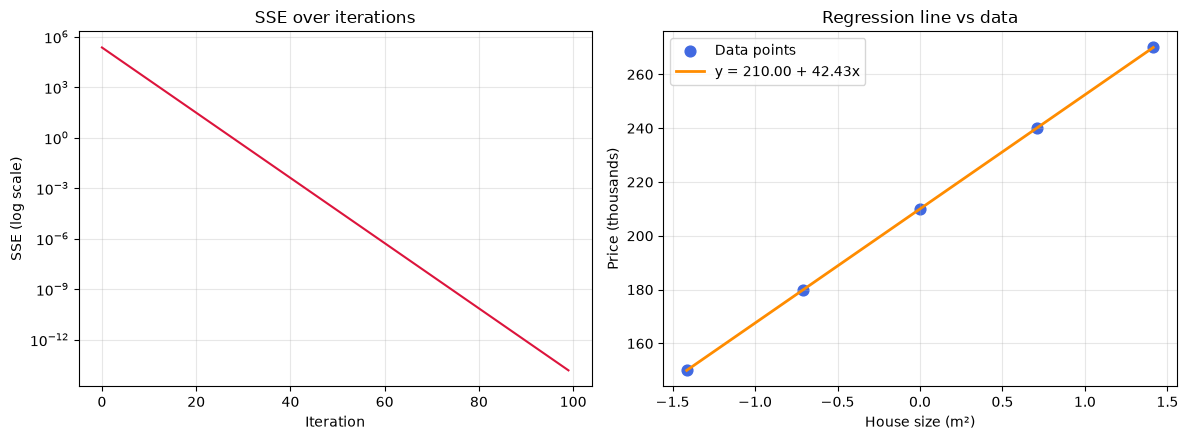

In [30]:
# التقارب أسرع بكتير مع lr أكبر بعد التطبيع
m_norm2 = LinearRegressionGD(learning_rate=0.1, n_iters=100).fit(X_norm, y)
print("[Normalized, lr=0.1] theta_0 =", round(m_norm2.theta_0, 4),
      "| theta_1 =", round(m_norm2.theta_1, 4),
      "| SSE =", round(m_norm2.sse_history[-1], 10))

m_norm2.plot_training(X_norm, y)

In [31]:
##  يوسف حسين